In [1]:
#pip install scikit-learn
print("hola")

hola


In [2]:
import yaml
import torch
from astroclip.models import SpecFormer 
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import ast
import ast
import numpy as np
from lightning.fabric.utilities.data import AttributeDict
from lightning.fabric.utilities.data import AttributeDict
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import accuracy_score, f1_score


c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\lightning\fabric\__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\dinov2\layers\attention.py:33: UserWarning: xFormers is not availab

# DATOS 

In [3]:
df = pd.read_csv("specter_completos.csv")
print(df["TType"].unique())
df.fillna(-99, inplace=True)
df['spectrum_flux'] = df['spectrum_flux'].apply(ast.literal_eval)
df['spectrum_flux'] = df['spectrum_flux'].apply(lambda x: np.array(x, dtype=np.float32))

# Tu DataFrame df y label_map
label_map = {-5:0, -3:1, -2:2, 0:3, 1:4, 2:5, 3:6, 4:7, 5:8, 6:9, 7:10, 8:11, 9:12, 10:13,11:14, 99:15,-99:16}

# Mapear los labels
mapped_labels = df['TType'].map(label_map)
#labels = torch.tensor(mapped_labels.values, dtype=torch.long)
#spectra = df['spectrum_flux'].apply(lambda x: torch.tensor(x, dtype=torch.float32))


[ 5.  0. -5.  2.  3.  4.  6. 99.  1. -3. -2.  7. 10.  9. nan 11.  8.]


In [4]:

from astroclip.models.astroclip import (
    AstroClipModel,
    ImageHead,
    SpectrumHead,
    CLIPLoss
)
from astroclip.modules import MLP, CrossAttentionHead
from astroclip.models.specformer import SpecFormer

# 1. Permitimos las clases del checkpoint
torch.serialization.add_safe_globals([
    AstroClipModel,
    ImageHead,
    SpectrumHead,
    SpecFormer,
    CLIPLoss,
    MLP,
    CrossAttentionHead
])

# 2. Cargamos el checkpoint
ckpt = torch.load("astroclip.ckpt", map_location="cpu", weights_only=False)

# 3. Recuperamos hyperparameters
hparams = ckpt["hyper_parameters"]

# 4. Inicializamos el modelo con los hyperparams del checkpoint
model = AstroClipModel(**hparams)

# 5. Restauramos pesos
model.load_state_dict(ckpt["state_dict"], strict=True)

model.eval()




c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
c:\Users\PabloL\Desktop\astro_model_tesis\AstroCLIP\entornoastro\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'spectrum_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['spectrum_encoder'])`.


AstroClipModel(
  (image_encoder): ImageHead(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(12, 12), stride=(12, 12))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0): BlockChunk(
          (0-5): 6 x NestedTensorBlock(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=1024, out_features=4096, bias=True)
              (act): GELU(approximate='none'

In [5]:
for param in model.parameters():
    param.requires_grad = False


In [6]:
import torch.nn as nn

class MorphologyClassifier(nn.Module):
    def __init__(self, input_dim=1024, num_classes=17):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [7]:
clf = MorphologyClassifier(input_dim=1024, num_classes=len(label_map))
clf = clf.to("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
import torchvision.transforms as T
from PIL import Image

img_transform = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor()
])

def embed_image(path):
    img = Image.open(path).convert("RGB")
    img = img_transform(img).unsqueeze(0)
    with torch.no_grad():
        e = model.image_encoder(img)
    return e.squeeze(0)


(7781,)


In [ ]:
import torch.nn.functional as F

def embed_spectrum(spec):
    # spec: tensor 1D (L,)
    slice_len = model.spectrum_encoder.backbone.hparams.slice_section_length
    
    # añadir batch y canal
    spec = spec.unsqueeze(0).unsqueeze(-1)  # (1, L, 1)
    
    # padding para que L sea múltiplo de slice_len
    L = spec.shape[1]
    pad_len = (slice_len - (L % slice_len)) % slice_len
    if pad_len > 0:
        spec = F.pad(spec, (0, 0, 0, pad_len), "constant", 0.0)
    
    spec = spec.to(device)
    with torch.no_grad():
        e = model.spectrum_encoder(spec)   # (1, embed_dim)
    
    return e.squeeze(0)  # (embed_dim,)


all_features = []
all_labels = []

for idx, row in df.iterrows():
    spectrum = torch.tensor(row["spectrum_flux"], dtype=torch.float32)

    jid = row["JID"]
    
    img_path = f"imagenes/{jid}.jpg"
    
    spec_emb = embed_spectrum(spectrum)

    img_emb  = embed_image(img_path)

    fused = torch.cat([spec_emb, img_emb], dim=-1)  # (1024,)

    all_features.append(fused)
    all_labels.append(label_map[row["TType"]])


torch.Size([7781])


IndexError: tuple index out of range

In [ ]:
X = torch.stack(all_features)   # (N, 1024)
y = torch.tensor(all_labels)    # (N,)


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X, y)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

criterion = nn.CrossEntropyLoss()
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
device = "cuda" if torch.cuda.is_available() else "cpu"

clf.train()
for epoch in range(10):
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        opt.zero_grad()
        logits = clf(xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print("Epoch", epoch, "loss", total_loss/len(loader))


# aqui obtenemos el encoder de espectros de astroclip

In [21]:


# Inicializar spectrum_encoder primero
spectrum_encoder = SpecFormer(
    input_dim=22,
    embed_dim=768,
    num_layers=6,
    num_heads=6,
    max_len=7781,
    dropout=0.1
)

# Cargar checkpoint permitiendo AttributeDict
with torch.serialization.safe_globals([AttributeDict]):
    checkpoint = torch.load("specformer.ckpt", map_location="cpu", weights_only=False)

# Extraer state_dict
state_dict = checkpoint.get("state_dict", checkpoint)

# Filtrar solo los pesos del spectrum_encoder
spectrum_state_dict = {
    k.replace("spectrum_encoder.", ""): v
    for k, v in state_dict.items() if "spectrum_encoder." in k
}

# Cargar los pesos en el encoder
spectrum_encoder.load_state_dict(spectrum_state_dict, strict=False)

# Inicializar el modelo completo



#epochs = 30


_IncompatibleKeys(missing_keys=['data_embed.weight', 'data_embed.bias', 'position_embed.weight', 'blocks.0.layernorm1.weight', 'blocks.0.layernorm1.bias', 'blocks.0.attention.attention.weight', 'blocks.0.attention.attention.bias', 'blocks.0.attention.projection.weight', 'blocks.0.attention.projection.bias', 'blocks.0.layernorm2.weight', 'blocks.0.layernorm2.bias', 'blocks.0.mlp.encoder.weight', 'blocks.0.mlp.encoder.bias', 'blocks.0.mlp.decoder.weight', 'blocks.0.mlp.decoder.bias', 'blocks.1.layernorm1.weight', 'blocks.1.layernorm1.bias', 'blocks.1.attention.attention.weight', 'blocks.1.attention.attention.bias', 'blocks.1.attention.projection.weight', 'blocks.1.attention.projection.bias', 'blocks.1.layernorm2.weight', 'blocks.1.layernorm2.bias', 'blocks.1.mlp.encoder.weight', 'blocks.1.mlp.encoder.bias', 'blocks.1.mlp.decoder.weight', 'blocks.1.mlp.decoder.bias', 'blocks.2.layernorm1.weight', 'blocks.2.layernorm1.bias', 'blocks.2.attention.attention.weight', 'blocks.2.attention.attent

In [22]:

df = pd.read_csv("specter_completos.csv")
print(df["TType"].unique())
df.fillna(-99, inplace=True)
df['spectrum_flux'] = df['spectrum_flux'].apply(ast.literal_eval)
df['spectrum_flux'] = df['spectrum_flux'].apply(lambda x: np.array(x, dtype=np.float32))

# Tu DataFrame df y label_map
label_map = {-5:0, -3:1, -2:2, 0:3, 1:4, 2:5, 3:6, 4:7, 5:8, 6:9, 7:10, 8:11, 9:12, 10:13,11:14, 99:15,-99:16}

# Mapear los labels
mapped_labels = df['TType'].map(label_map)
labels = torch.tensor(mapped_labels.values, dtype=torch.long)
spectra = df['spectrum_flux'].apply(lambda x: torch.tensor(x, dtype=torch.float32))

spectra_train, spectra_test, labels_train, labels_test = train_test_split(
    spectra, labels, test_size=0.2, random_state=42, stratify=labels
)


class SpectrumDataset(Dataset):
    def __init__(self, spectra, labels):
        self.spectra = list(spectra)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.spectra)

    def __getitem__(self, idx):
        return self.spectra[idx], self.labels[idx]

dataset = SpectrumDataset(spectra, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Crear datasets
train_dataset = SpectrumDataset(spectra_train, labels_train)
test_dataset  = SpectrumDataset(spectra_test, labels_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


C:\Users\PabloL\AppData\Local\Temp\3\ipykernel_9680\4267519126.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.long)


In [4]:
# Mover modelo a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Definir optimizador y función de pérdida
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-1,
    betas=(0.9, 0.95)
)

criterion = torch.nn.CrossEntropyLoss() 

In [5]:
import torch.nn as nn


embedding_dim = 768
num_classes = 17  # ajusta según tus etiquetas

classifier_head = nn.Sequential(
    nn.Linear(embedding_dim, 512),
    nn.ReLU(),
    nn.Linear(512, num_classes)  # output [B, num_classes]
).to(device)


model.train()  # activar modo entrenamiento

AstroClipModel(
  (spectrum_encoder): SpecFormer(
    (data_embed): Linear(in_features=22, out_features=768, bias=True)
    (position_embed): Embedding(7781, 768)
    (dropout): Dropout(p=0.1, inplace=False)
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (layernorm1): LayerNorm()
        (attention): SelfAttention(
          (attention): Linear(in_features=768, out_features=2304, bias=True)
          (projection): Linear(in_features=768, out_features=768, bias=True)
          (attention_dropout): Dropout(p=0.1, inplace=False)
          (residual_dropout): Dropout(p=0.1, inplace=False)
        )
        (layernorm2): LayerNorm()
        (mlp): MLP(
          (activation): GELU(approximate='none')
          (encoder): Linear(in_features=768, out_features=3072, bias=True)
          (decoder): Linear(in_features=3072, out_features=768, bias=True)
          (dropout_layer): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (final_layernorm): LayerNorm()
    (he

In [9]:




for epoch in range(epochs):
    running_loss = 0.0
    for batch_spectra, batch_labels in dataloader:
        batch_spectra = batch_spectra.unsqueeze(-1).to(device)  # [B, L, 1]
        batch_labels = batch_labels.to(device)                  # [B]

        optimizer.zero_grad()

        # Obtener embeddings
        outputs = model.spectrum_encoder(batch_spectra)
        embeddings = outputs['embedding']                       # [B, embedding_dim]

        
        logits = classifier_head(embeddings)                   # [B, num_classes]
        logits = logits[:, 0, :] 
        # Calcular loss
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(dataloader):.4f}")



Epoch 1/30, Loss: 2.2847
Epoch 2/30, Loss: 2.2859
Epoch 3/30, Loss: 2.2826
Epoch 4/30, Loss: 2.2747
Epoch 5/30, Loss: 2.2856
Epoch 6/30, Loss: 2.2743
Epoch 7/30, Loss: 2.2749
Epoch 8/30, Loss: 2.2746
Epoch 9/30, Loss: 2.2815
Epoch 10/30, Loss: 2.2722
Epoch 11/30, Loss: 2.2732
Epoch 12/30, Loss: 2.2744
Epoch 13/30, Loss: 2.2724
Epoch 14/30, Loss: 2.2712
Epoch 15/30, Loss: 2.2726
Epoch 16/30, Loss: 2.2723
Epoch 17/30, Loss: 2.2690
Epoch 18/30, Loss: 2.2688
Epoch 19/30, Loss: 2.2712
Epoch 20/30, Loss: 2.2695
Epoch 21/30, Loss: 2.2660
Epoch 22/30, Loss: 2.2718
Epoch 23/30, Loss: 2.2662
Epoch 24/30, Loss: 2.2697
Epoch 25/30, Loss: 2.2689
Epoch 26/30, Loss: 2.2722
Epoch 27/30, Loss: 2.2733
Epoch 28/30, Loss: 2.2718
Epoch 29/30, Loss: 2.2695
Epoch 30/30, Loss: 2.2671


Epoch 1/30 | Train Loss: 2.3743 | Train Acc: 0.1714 | Train F1: 0.0531 | Val Loss: 2.3328 | Val Acc: 0.1992 | Val F1: 0.0575
Epoch 2/30 | Train Loss: 2.3385 | Train Acc: 0.1910 | Train F1: 0.0593 | Val Loss: 2.3197 | Val Acc: 0.2070 | Val F1: 0.0538
Epoch 3/30 | Train Loss: 2.3211 | Train Acc: 0.1841 | Train F1: 0.0630 | Val Loss: 2.3061 | Val Acc: 0.1914 | Val F1: 0.0554
Epoch 4/30 | Train Loss: 2.3163 | Train Acc: 0.1753 | Train F1: 0.0580 | Val Loss: 2.2948 | Val Acc: 0.2031 | Val F1: 0.0609
Epoch 5/30 | Train Loss: 2.3121 | Train Acc: 0.1783 | Train F1: 0.0525 | Val Loss: 2.2800 | Val Acc: 0.2070 | Val F1: 0.0578
Epoch 6/30 | Train Loss: 2.2980 | Train Acc: 0.1773 | Train F1: 0.0533 | Val Loss: 2.2817 | Val Acc: 0.1914 | Val F1: 0.0551
Epoch 7/30 | Train Loss: 2.2902 | Train Acc: 0.1900 | Train F1: 0.0583 | Val Loss: 2.2703 | Val Acc: 0.1992 | Val F1: 0.0571
Epoch 8/30 | Train Loss: 2.2886 | Train Acc: 0.1939 | Train F1: 0.0575 | Val Loss: 2.2686 | Val Acc: 0.1719 | Val F1: 0.0456


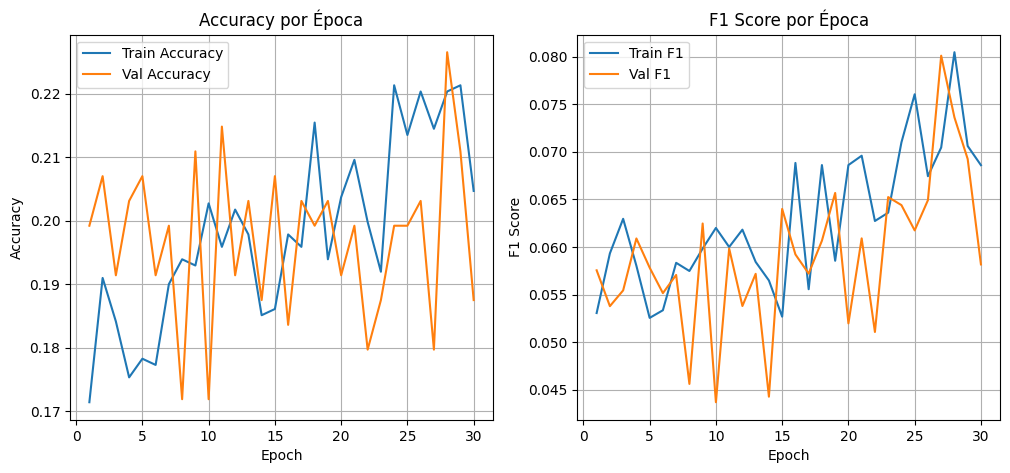

In [15]:


# Listas para guardar métricas
train_acc_list, val_acc_list = [], []
train_f1_list, val_f1_list = [], []
model.train()
classifier_head.train()
for epoch in range(epochs):
    
    

    running_loss = 0.0
    train_preds, train_labels = [], []

    for spectra, labels in train_loader:
        spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
        optimizer.zero_grad()

        
        emb = model.spectrum_encoder(spectra)["embedding"]

        logits = classifier_head(emb)
       # print(logits.shape)
        logits = logits[:, 0, :] 
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    train_acc_list.append(train_acc)
    train_f1_list.append(train_f1)

    # ---- VALIDATION ----
    model.eval()
    classifier_head.eval()

    val_preds, val_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for spectra, labels in test_loader:
            spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
            emb = model.spectrum_encoder(spectra)["embedding"]
            logits = classifier_head(emb)
            logits = logits[:, 0, :] 
            loss = criterion(logits, labels)
            val_loss += loss.item()

            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_acc_list.append(val_acc)
    val_f1_list.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss/len(test_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# ---- GRAFICAR METRICAS ----
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_acc_list, label="Train Accuracy")
plt.plot(range(1, epochs+1), val_acc_list, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por Época")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_f1_list, label="Train F1")
plt.plot(range(1, epochs+1), val_f1_list, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score por Época")
plt.legend()
plt.grid(True)

plt.show()


Epoch 1/10 | Train Loss: 2.2191 | Train Acc: 0.2027 | Train F1: 0.0765 | Val Loss: 2.2108 | Val Acc: 0.2109 | Val F1: 0.0889
Epoch 2/10 | Train Loss: 2.1845 | Train Acc: 0.2243 | Train F1: 0.0848 | Val Loss: 2.2057 | Val Acc: 0.1836 | Val F1: 0.0776
Epoch 3/10 | Train Loss: 2.1906 | Train Acc: 0.2135 | Train F1: 0.0852 | Val Loss: 2.2118 | Val Acc: 0.2188 | Val F1: 0.0834
Epoch 4/10 | Train Loss: 2.1831 | Train Acc: 0.2233 | Train F1: 0.0887 | Val Loss: 2.2060 | Val Acc: 0.2070 | Val F1: 0.0882
Epoch 5/10 | Train Loss: 2.1801 | Train Acc: 0.2184 | Train F1: 0.0819 | Val Loss: 2.2157 | Val Acc: 0.1992 | Val F1: 0.0784
Epoch 6/10 | Train Loss: 2.1785 | Train Acc: 0.2057 | Train F1: 0.0815 | Val Loss: 2.2144 | Val Acc: 0.2031 | Val F1: 0.0690
Epoch 7/10 | Train Loss: 2.1858 | Train Acc: 0.2096 | Train F1: 0.0792 | Val Loss: 2.2550 | Val Acc: 0.1797 | Val F1: 0.0457
Epoch 8/10 | Train Loss: 2.1970 | Train Acc: 0.2047 | Train F1: 0.0762 | Val Loss: 2.1977 | Val Acc: 0.2344 | Val F1: 0.1037


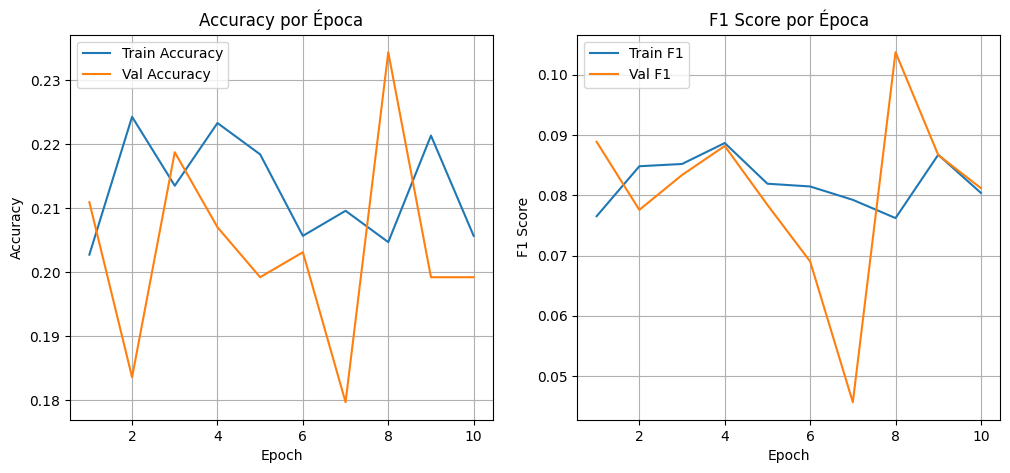

In [19]:
# Listas para guardar métricas
train_acc_list, val_acc_list = [], []
train_f1_list, val_f1_list = [], []
model.train()
classifier_head.train()
for epoch in range(epochs):
    
    

    running_loss = 0.0
    train_preds, train_labels = [], []

    for spectra, labels in train_loader:
        spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
        optimizer.zero_grad()

        
        emb = model.spectrum_encoder(spectra)["embedding"]

        logits = classifier_head(emb)
       # print(logits.shape)
        logits = logits[:, 0, :] 
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    train_acc_list.append(train_acc)
    train_f1_list.append(train_f1)

    # ---- VALIDATION ----
    model.eval()
    classifier_head.eval()

    val_preds, val_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for spectra, labels in test_loader:
            spectra, labels = spectra.unsqueeze(-1).to(device), labels.to(device)
            emb = model.spectrum_encoder(spectra)["embedding"]
            logits = classifier_head(emb)
            logits = logits[:, 0, :] 
            loss = criterion(logits, labels)
            val_loss += loss.item()

            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_acc_list.append(val_acc)
    val_f1_list.append(val_f1)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss/len(test_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# ---- GRAFICAR METRICAS ----
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_acc_list, label="Train Accuracy")
plt.plot(range(1, epochs+1), val_acc_list, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por Época")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_f1_list, label="Train F1")
plt.plot(range(1, epochs+1), val_f1_list, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score por Época")
plt.legend()
plt.grid(True)

plt.show()
